In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/Credit Card Fraud Dataset.csv")

# Check target distribution
print(df['is_fraud'].value_counts())


is_fraud
0    9849
1     151
Name: count, dtype: int64


In [2]:
# Separate target
y = df['is_fraud']

# Drop target and non-useful columns (example: Time)
X = df.drop(columns=['is_fraud', 'Time'], errors='ignore')


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other (numerical) columns as they are
)

# Create a pipeline with preprocessing and logistic regression
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['merchant_category'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical columns (from X_train already defined)
categorical_features = X_train.select_dtypes(include=['object']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other (numerical) columns as they are
)

# Create a pipeline with preprocessing and RandomForestClassifier
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['merchant_category'], dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [13]:
from sklearn.metrics import classification_report

# Logistic Regression evaluation
log_preds = log_model.predict(X_test)
print("Logistic Regression Report")
print(classification_report(y_test, log_preds))

# Random Forest evaluation
rf_preds = rf_model.predict(X_test)
print("Random Forest Report")
print(classification_report(y_test, rf_preds))


Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1970
           1       0.26      1.00      0.41        30

    accuracy                           0.96      2000
   macro avg       0.63      0.98      0.69      2000
weighted avg       0.99      0.96      0.97      2000

Random Forest Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.43      0.60        30

    accuracy                           0.99      2000
   macro avg       1.00      0.72      0.80      2000
weighted avg       0.99      0.99      0.99      2000



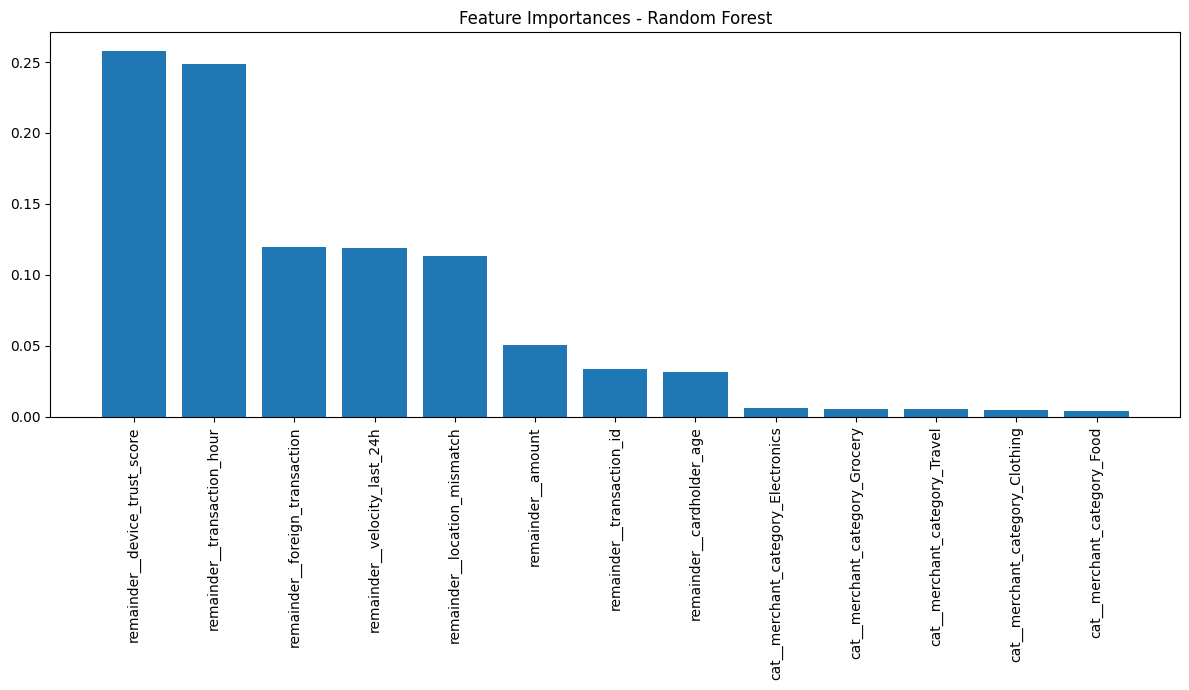

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Access the RandomForestClassifier from the pipeline to get feature importances
importances = rf_model.named_steps['classifier'].feature_importances_

# Get the feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Sort feature importances and get corresponding indices
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 7))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    "Logistic Regression": log_preds,
    "Random Forest": rf_preds
}

for name, preds in models.items():
    print(f"\n{name}")
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1-score:", f1_score(y_test, preds))



Logistic Regression
Precision: 0.2564102564102564
Recall: 1.0
F1-score: 0.40816326530612246

Random Forest
Precision: 1.0
Recall: 0.43333333333333335
F1-score: 0.6046511627906976


In [17]:
import joblib

# Save Random Forest (usually better for fraud detection)
joblib.dump(rf_model, "fraud_detection_model.pkl")


['fraud_detection_model.pkl']

In [18]:
loaded_model = joblib.load("fraud_detection_model.pkl")
